In [1]:
##imports y rutas
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
DOCS_DIR = PROJECT_ROOT / "docs"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SCALED_PATH = DATA_DIR / "dataset_scaled.csv"
DATASET_ORIGINAL_PATH = DATA_DIR / "dataset.csv"

BASE_MODEL_PATH = MODELS_DIR / "rf_model.pkl"
OPTIMIZED_MODEL_PATH = MODELS_DIR / "rf_optimized.pkl"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"
SCALER_PATH = MODELS_DIR / "scaler.pkl"

OPTIMIZATION_DOC_PATH = DOCS_DIR / "hyperparameter_optimization.md"
OPTIMIZATION_JSON_PATH = DOCS_DIR / "hyperparameter_optimization_metrics.json"

COMPARISON_FIGURE_PATH = FIGURES_DIR / "rf_base_vs_optimized.png"
OPTIMIZED_CM_PATH = FIGURES_DIR / "rf_optimized_confusion_matrix.png"
OPTIMIZED_FI_PATH = FIGURES_DIR / "rf_optimized_feature_importance_top10.png"

print("Project root:", PROJECT_ROOT)
print("Scaled dataset exists:", DATASET_SCALED_PATH.exists())
print("Original dataset exists:", DATASET_ORIGINAL_PATH.exists())
print("Base RF model exists:", BASE_MODEL_PATH.exists())
print("Label encoder exists:", LABEL_ENCODER_PATH.exists())

Project root: /home/angel/projects/CNC_Project
Scaled dataset exists: True
Original dataset exists: True
Base RF model exists: True
Label encoder exists: True


In [2]:
##cargar modelo base, dataset y encoder
df_scaled = pd.read_csv(DATASET_SCALED_PATH)
df_original = pd.read_csv(DATASET_ORIGINAL_PATH)

base_model = joblib.load(BASE_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Scaled dataset shape:", df_scaled.shape)
print("Original dataset shape:", df_original.shape)
print("Classes:", list(label_encoder.classes_))

display(df_scaled.head())

Scaled dataset shape: (491, 29)
Original dataset shape: (491, 29)
Classes: ['icmp_flood', 'normal', 'port_sweep', 'syn_scan', 'udp_scan']


,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,...,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing,label
0,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
1,-0.869255,1.818521,0.794499,1.229215,0.818577,1.545013,0.818577,1.265758,0.931085,0.931085,...,-0.794499,-0.794499,-0.794499,-2.002549,-0.931085,-0.931085,-0.931085,-0.931085,-0.931085,normal
2,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
3,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
4,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan


In [3]:
##reconstruir X e Y igual que los días anteriores
LABEL_COL = "label"

non_feature_cols = {
    "label",
    "cluster",
    "flow_id",
    "id",
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "application_name",
    "application_category_name",
    "requested_server_name",
    "client_fingerprint",
    "server_fingerprint",
    "user_agent",
    "content_type",
    "pcap_file",
    "pcap_path",
    "filename",
    "timestamp",
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
}

numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    col for col in numeric_cols
    if col not in non_feature_cols
]

X = df_scaled[feature_cols].copy()
y_raw = df_scaled[LABEL_COL].copy()
y = label_encoder.transform(y_raw)

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for col in feature_cols:
    print("-", col)

print("\nAny NaN?", X.isna().any().any())
print("Any inf?", np.isinf(X.to_numpy()).any())

Number of features: 28
X shape: (491, 28)
y shape: (491,)

Features:
- protocol
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- dst2src_packets
- src2dst_bytes
- dst2src_bytes
- bidirectional_mean_ps
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- bytes_asymmetry_ratio
- packets_asymmetry_ratio
- bidirectional_packets_per_ms
- bytes_per_packet
- manual_packet_count
- iat_mean_ms
- duration_zero_flag
- syn_ack_ratio_nfstream_missing
- iat_mean_ms_missing
- iat_std_ms_missing
- iat_cv_missing
- rtt_estimate_ms_missing
- tcp_window_min_missing
- tcp_window_max_missing
- tcp_window_mean_missing
- tcp_window_var_missing
- syn_ack_ratio_manual_missing

Any NaN? False
Any inf? False


In [4]:
##guardar/verificar models/scaler.pkl
if SCALER_PATH.exists():
    scaler = joblib.load(SCALER_PATH)
    print("Existing scaler loaded from:", SCALER_PATH)
else:
    print("Scaler not found. Recreating StandardScaler from original dataset.")

    raw_numeric_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
    raw_feature_cols = [
        col for col in raw_numeric_cols
        if col in feature_cols
    ]

    if set(raw_feature_cols) != set(feature_cols):
        missing = set(feature_cols) - set(raw_feature_cols)
        raise ValueError(f"Cannot recreate scaler. Missing original columns: {missing}")

    X_raw = df_original[feature_cols].copy()

    scaler = StandardScaler()
    scaler.fit(X_raw)

    joblib.dump(scaler, SCALER_PATH)
    print("Scaler saved to:", SCALER_PATH)

Existing scaler loaded from: /home/angel/projects/CNC_Project/models/scaler.pkl


In [5]:
##train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

target_names = label_encoder.classes_

train_distribution = pd.Series(
    label_encoder.inverse_transform(y_train),
    name="label"
).value_counts().sort_index()

test_distribution = pd.Series(
    label_encoder.inverse_transform(y_test),
    name="label"
).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "train_count": train_distribution,
    "test_count": test_distribution
})

display(split_distribution)

,train_count,test_count
label,,
icmp_flood,49,12
normal,103,26
port_sweep,34,9
syn_scan,103,26
udp_scan,103,26


In [6]:
##evaluar modelo base
base_train_pred = base_model.predict(X_train)
base_test_pred = base_model.predict(X_test)

base_train_accuracy = accuracy_score(y_train, base_train_pred)
base_test_accuracy = accuracy_score(y_test, base_test_pred)
base_accuracy_gap = base_train_accuracy - base_test_accuracy
base_weighted_f1 = f1_score(y_test, base_test_pred, average="weighted")

base_report_dict = classification_report(
    y_test,
    base_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

print(f"Base train accuracy: {base_train_accuracy:.4f}")
print(f"Base test accuracy:  {base_test_accuracy:.4f}")
print(f"Base accuracy gap:   {base_accuracy_gap:.4f}")
print(f"Base weighted F1:    {base_weighted_f1:.4f}")

Base train accuracy: 0.9796
Base test accuracy:  0.9697
Base accuracy gap:   0.0099
Base weighted F1:    0.9689


In [7]:
##definir espacio de búsqueda
param_distributions = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_for_search = RandomForestClassifier(
    random_state=RANDOM_STATE
)

random_search = RandomizedSearchCV(
    estimator=rf_for_search,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1_weighted",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("RandomizedSearchCV configured.")

RandomizedSearchCV configured.


In [8]:
##ejecutar RandomizedSearchCV
random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print(f"\nBest CV weighted F1: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20}

Best CV weighted F1: 0.9519


In [9]:
##analizar los resultados de la búsqueda
search_results = pd.DataFrame(random_search.cv_results_)

important_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_max_features"
]

search_results_summary = (
    search_results[important_cols]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(search_results_summary.head(20).round(4))

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_n_estimators,param_max_depth,param_min_samples_split,param_max_features
0,1,0.9519,0.0254,0.9767,0.0041,200,None,5,sqrt
1,1,0.9519,0.0254,0.9767,0.0041,200,None,10,log2
2,1,0.9519,0.0254,0.9767,0.0041,200,20,10,sqrt
3,1,0.9519,0.0254,0.9767,0.0041,200,10,5,log2
4,1,0.9519,0.0254,0.9767,0.0041,200,None,10,sqrt
5,1,0.9519,0.0254,0.9767,0.0041,200,10,10,sqrt
6,7,0.9498,0.0240,0.9768,0.0035,50,20,5,log2
7,7,0.9498,0.0240,0.9768,0.0035,50,None,5,log2
8,9,0.9498,0.0240,0.9769,0.0040,100,None,5,sqrt
9,9,0.9498,0.0240,0.9762,0.0035,100,20,10,log2


In [10]:
##guardar resultados
search_results_path = DOCS_DIR / "randomized_search_results.csv"
search_results_summary.to_csv(search_results_path, index=False)

print("Randomized search results saved to:", search_results_path)

Randomized search results saved to: /home/angel/projects/CNC_Project/docs/randomized_search_results.csv


In [11]:
##entrenar/obtener modelo optimizado
best_rf_model = random_search.best_estimator_

print(best_rf_model)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=200,
                       random_state=42)


In [12]:
##guardar
joblib.dump(best_rf_model, OPTIMIZED_MODEL_PATH)

print("Optimized RF model saved to:", OPTIMIZED_MODEL_PATH)

Optimized RF model saved to: /home/angel/projects/CNC_Project/models/rf_optimized.pkl


In [13]:
##evaluar modelo optimizado en train/test
opt_train_pred = best_rf_model.predict(X_train)
opt_test_pred = best_rf_model.predict(X_test)

opt_train_accuracy = accuracy_score(y_train, opt_train_pred)
opt_test_accuracy = accuracy_score(y_test, opt_test_pred)
opt_accuracy_gap = opt_train_accuracy - opt_test_accuracy
opt_weighted_f1 = f1_score(y_test, opt_test_pred, average="weighted")

opt_report_dict = classification_report(
    y_test,
    opt_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

print(f"Optimized train accuracy: {opt_train_accuracy:.4f}")
print(f"Optimized test accuracy:  {opt_test_accuracy:.4f}")
print(f"Optimized accuracy gap:   {opt_accuracy_gap:.4f}")
print(f"Optimized weighted F1:    {opt_weighted_f1:.4f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    opt_test_pred,
    target_names=target_names,
    zero_division=0
))

Optimized train accuracy: 0.9745
Optimized test accuracy:  0.9798
Optimized accuracy gap:   -0.0053
Optimized weighted F1:    0.9797

Classification report:
              precision    recall  f1-score   support

  icmp_flood       0.92      1.00      0.96        12
      normal       1.00      0.96      0.98        26
  port_sweep       1.00      0.89      0.94         9
    syn_scan       0.96      1.00      0.98        26
    udp_scan       1.00      1.00      1.00        26

    accuracy                           0.98        99
   macro avg       0.98      0.97      0.97        99
weighted avg       0.98      0.98      0.98        99



In [14]:
##comparar modelo base vs optimizado
comparison_df = pd.DataFrame([
    {
        "model": "Random Forest Base",
        "train_accuracy": base_train_accuracy,
        "test_accuracy": base_test_accuracy,
        "accuracy_gap": base_accuracy_gap,
        "weighted_f1": base_weighted_f1
    },
    {
        "model": "Random Forest Optimized",
        "train_accuracy": opt_train_accuracy,
        "test_accuracy": opt_test_accuracy,
        "accuracy_gap": opt_accuracy_gap,
        "weighted_f1": opt_weighted_f1
    }
])

display(comparison_df.round(4))

,model,train_accuracy,test_accuracy,accuracy_gap,weighted_f1
0,Random Forest Base,0.9796,0.9697,0.0099,0.9689
1,Random Forest Optimized,0.9745,0.9798,-0.0053,0.9797


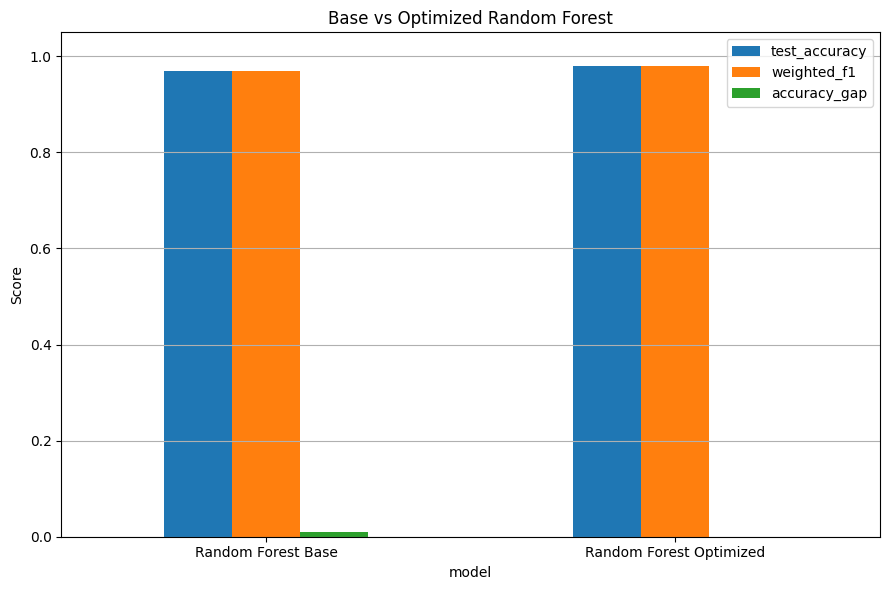

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_base_vs_optimized.png


In [15]:
##figura
plot_df = comparison_df.set_index("model")[[
    "test_accuracy",
    "weighted_f1",
    "accuracy_gap"
]]

ax = plot_df.plot(kind="bar", figsize=(9, 6))

plt.title("Base vs Optimized Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(COMPARISON_FIGURE_PATH, dpi=300)
plt.show()

print("Saved:", COMPARISON_FIGURE_PATH)

,icmp_flood,normal,port_sweep,syn_scan,udp_scan
icmp_flood,12,0,0,0,0
normal,1,25,0,0,0
port_sweep,0,0,8,1,0
syn_scan,0,0,0,26,0
udp_scan,0,0,0,0,26


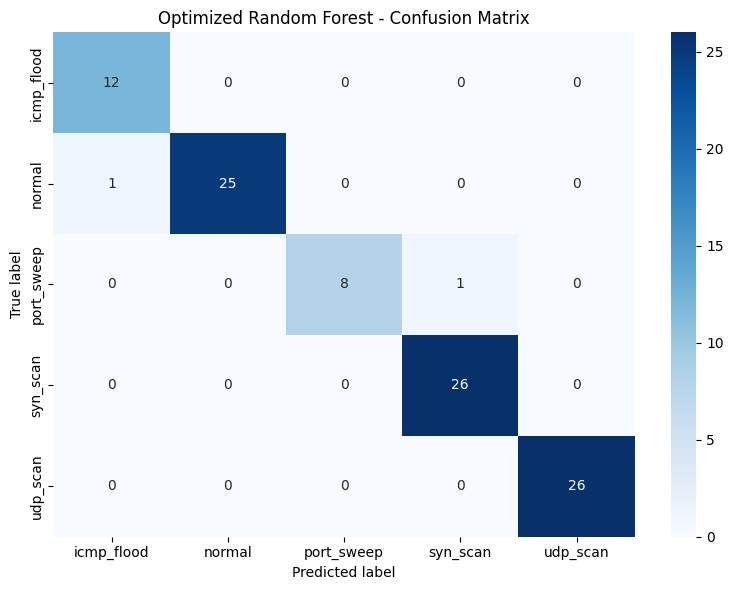

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_optimized_confusion_matrix.png


In [16]:
##amtriz de confusión del modelo optimizado
opt_cm = confusion_matrix(y_test, opt_test_pred)

opt_cm_df = pd.DataFrame(
    opt_cm,
    index=target_names,
    columns=target_names
)

display(opt_cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    opt_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Optimized Random Forest - Confusion Matrix")
plt.tight_layout()

plt.savefig(OPTIMIZED_CM_PATH, dpi=300)
plt.show()

print("Saved:", OPTIMIZED_CM_PATH)

In [17]:
##feature importance del modelo optimizado
opt_feature_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(opt_feature_importances.head(15).round(4))

,feature,importance
5,src2dst_bytes,0.1676
14,bytes_per_packet,0.1396
16,iat_mean_ms,0.1336
3,bidirectional_bytes,0.1157
7,bidirectional_mean_ps,0.1021
10,bidirectional_rst_packets,0.0545
2,bidirectional_packets,0.0273
19,iat_mean_ms_missing,0.0259
21,iat_cv_missing,0.0256
20,iat_std_ms_missing,0.0251


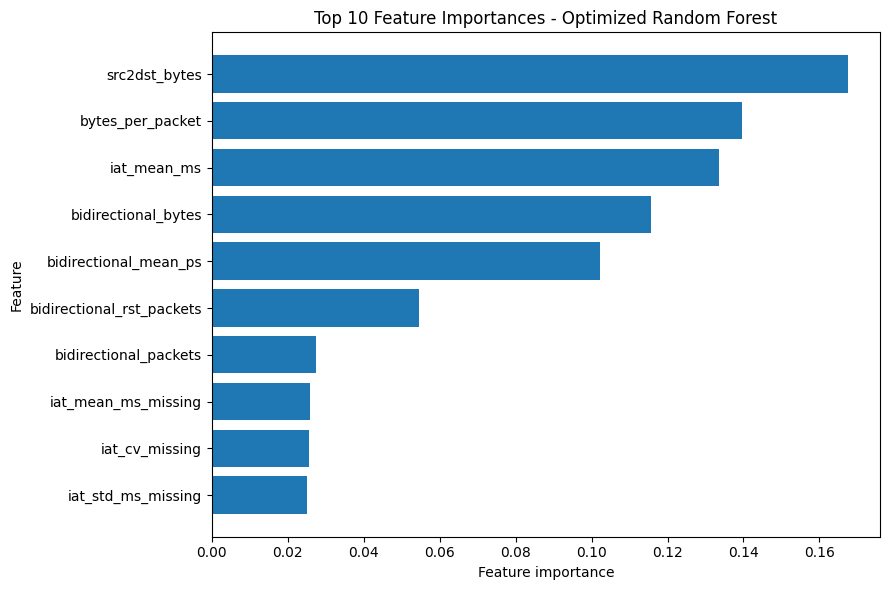

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_optimized_feature_importance_top10.png


In [18]:
##figura
top_n = 10
top_features = opt_feature_importances.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Optimized Random Forest")
plt.tight_layout()

plt.savefig(OPTIMIZED_FI_PATH, dpi=300)
plt.show()

print("Saved:", OPTIMIZED_FI_PATH)

In [19]:
##cross-validation del modelo optimizado
optimized_cv_model = RandomForestClassifier(
    **random_search.best_params_,
    random_state=RANDOM_STATE
)

opt_cv_f1_scores = cross_val_score(
    optimized_cv_model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted"
)

opt_cv_accuracy_scores = cross_val_score(
    optimized_cv_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Optimized CV F1 weighted scores:", opt_cv_f1_scores)
print(f"Optimized CV mean F1 weighted: {opt_cv_f1_scores.mean():.4f}")
print(f"Optimized CV std F1 weighted:  {opt_cv_f1_scores.std():.4f}")

print("\nOptimized CV accuracy scores:", opt_cv_accuracy_scores)
print(f"Optimized CV mean accuracy: {opt_cv_accuracy_scores.mean():.4f}")
print(f"Optimized CV std accuracy:  {opt_cv_accuracy_scores.std():.4f}")

Optimized CV F1 weighted scores: [0.94582185 0.9792224  0.97987676 0.98959206 0.93130159]
Optimized CV mean F1 weighted: 0.9652
Optimized CV std F1 weighted:  0.0225

Optimized CV accuracy scores: [0.94949495 0.97959184 0.97959184 0.98979592 0.93877551]
Optimized CV mean accuracy: 0.9675
Optimized CV std accuracy:  0.0197


In [20]:
## Cross-validation del modelo base para comparación reproducible

base_cv_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

base_cv_f1_scores = cross_val_score(
    base_cv_model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted"
)

base_cv_accuracy_scores = cross_val_score(
    base_cv_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Base CV F1 weighted scores:", base_cv_f1_scores)
print(f"Base CV mean F1 weighted: {base_cv_f1_scores.mean():.4f}")
print(f"Base CV std F1 weighted:  {base_cv_f1_scores.std():.4f}")

print("\nBase CV accuracy scores:", base_cv_accuracy_scores)
print(f"Base CV mean accuracy: {base_cv_accuracy_scores.mean():.4f}")
print(f"Base CV std accuracy:  {base_cv_accuracy_scores.std():.4f}")

Base CV F1 weighted scores: [0.96909158 0.9681824  0.97987676 0.98959206 0.93130159]
Base CV mean F1 weighted: 0.9676
Base CV std F1 weighted:  0.0198

Base CV accuracy scores: [0.96969697 0.96938776 0.97959184 0.98979592 0.93877551]
Base CV mean accuracy: 0.9694
Base CV std accuracy:  0.0171


In [21]:
## Decidir modelo final con test split + cross-validation

base_cv_f1_mean = float(base_cv_f1_scores.mean())
base_cv_f1_std = float(base_cv_f1_scores.std())
base_cv_accuracy_mean = float(base_cv_accuracy_scores.mean())
base_cv_accuracy_std = float(base_cv_accuracy_scores.std())

opt_cv_f1_mean = float(opt_cv_f1_scores.mean())
opt_cv_f1_std = float(opt_cv_f1_scores.std())
opt_cv_accuracy_mean = float(opt_cv_accuracy_scores.mean())
opt_cv_accuracy_std = float(opt_cv_accuracy_scores.std())

model_selection_summary = {
    "base_weighted_f1_test": float(base_weighted_f1),
    "optimized_weighted_f1_test": float(opt_weighted_f1),
    "base_accuracy_gap": float(base_accuracy_gap),
    "optimized_accuracy_gap": float(opt_accuracy_gap),
    "base_cv_f1_mean": base_cv_f1_mean,
    "optimized_cv_f1_mean": opt_cv_f1_mean,
    "base_cv_f1_std": base_cv_f1_std,
    "optimized_cv_f1_std": opt_cv_f1_std,
    "base_cv_accuracy_mean": base_cv_accuracy_mean,
    "optimized_cv_accuracy_mean": opt_cv_accuracy_mean,
    "base_cv_accuracy_std": base_cv_accuracy_std,
    "optimized_cv_accuracy_std": opt_cv_accuracy_std,
}

display(pd.DataFrame([model_selection_summary]).round(4))

cv_tolerance = 0.005

if (
    opt_weighted_f1 > base_weighted_f1
    and opt_accuracy_gap <= 0.05
    and opt_cv_f1_mean >= base_cv_f1_mean - cv_tolerance
):
    final_model_decision = "optimized_model_selected"
    final_model_reason = (
        "The optimized model is selected because it improves the held-out test weighted F1-score "
        "and keeps the train-test gap below 5%. Although its cross-validation mean F1 is slightly "
        "lower than the baseline, the difference is small and within the defined tolerance. Therefore, "
        "the optimized model offers a better test performance while maintaining acceptable cross-validation stability."
    )
else:
    final_model_decision = "baseline_model_preferred"
    final_model_reason = (
        "The baseline model is preferred because the optimized model does not provide a sufficiently "
        "robust improvement when both held-out test performance and cross-validation stability are considered."
    )

print("Final model decision:", final_model_decision)
print("Reason:", final_model_reason)

,base_weighted_f1_test,optimized_weighted_f1_test,base_accuracy_gap,optimized_accuracy_gap,base_cv_f1_mean,optimized_cv_f1_mean,base_cv_f1_std,optimized_cv_f1_std,base_cv_accuracy_mean,optimized_cv_accuracy_mean,base_cv_accuracy_std,optimized_cv_accuracy_std
0,0.9689,0.9797,0.0099,-0.0053,0.9676,0.9652,0.0198,0.0225,0.9694,0.9675,0.0171,0.0197


Final model decision: optimized_model_selected
Reason: The optimized model is selected because it improves the held-out test weighted F1-score and keeps the train-test gap below 5%. Although its cross-validation mean F1 is slightly lower than the baseline, the difference is small and within the defined tolerance. Therefore, the optimized model offers a better test performance while maintaining acceptable cross-validation stability.


In [22]:
##guardar métricas en JSON
optimization_metrics = {
    "search_space": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"],
    },
    "randomized_search": {
        "n_iter": 20,
        "cv": 5,
        "scoring": "f1_weighted",
        "best_params": random_search.best_params_,
        "best_cv_score": float(random_search.best_score_),
    },
    "base_model": {
    "train_accuracy": float(base_train_accuracy),
    "test_accuracy": float(base_test_accuracy),
    "accuracy_gap": float(base_accuracy_gap),
    "weighted_f1": float(base_weighted_f1),
    "cv_f1_scores": base_cv_f1_scores.tolist(),
    "cv_f1_mean": float(base_cv_f1_scores.mean()),
    "cv_f1_std": float(base_cv_f1_scores.std()),
    "cv_accuracy_scores": base_cv_accuracy_scores.tolist(),
    "cv_accuracy_mean": float(base_cv_accuracy_scores.mean()),
    "cv_accuracy_std": float(base_cv_accuracy_scores.std()),
},
    "optimized_model": {
        "train_accuracy": float(opt_train_accuracy),
        "test_accuracy": float(opt_test_accuracy),
        "accuracy_gap": float(opt_accuracy_gap),
        "weighted_f1": float(opt_weighted_f1),
        "classification_report": opt_report_dict,
        "cv_f1_scores": opt_cv_f1_scores.tolist(),
        "cv_f1_mean": float(opt_cv_f1_scores.mean()),
        "cv_f1_std": float(opt_cv_f1_scores.std()),
        "cv_accuracy_scores": opt_cv_accuracy_scores.tolist(),
        "cv_accuracy_mean": float(opt_cv_accuracy_scores.mean()),
        "cv_accuracy_std": float(opt_cv_accuracy_scores.std()),
        "top_10_features": opt_feature_importances.head(10).to_dict(orient="records"),
    },
    "model_selection": {
        "decision": final_model_decision,
        "reason": final_model_reason,
    }
}

with OPTIMIZATION_JSON_PATH.open("w", encoding="utf-8") as f:
    json.dump(optimization_metrics, f, indent=2)

print("Saved:", OPTIMIZATION_JSON_PATH)

Saved: /home/angel/projects/CNC_Project/docs/hyperparameter_optimization_metrics.json


In [23]:
##generar documentación
lines = []

lines.append("# Random Forest Hyperparameter Optimization\n")

lines.append("## Objective\n")
lines.append(
    "The objective of this stage is to evaluate whether the baseline Random Forest can be improved "
    "through hyperparameter optimization while keeping the model robust and avoiding overfitting.\n"
)

lines.append("## Search strategy\n")
lines.append("- Method: `RandomizedSearchCV`\n")
lines.append("- Number of sampled configurations: `n_iter=20`\n")
lines.append("- Cross-validation: `5-fold StratifiedKFold`\n")
lines.append("- Scoring metric: `f1_weighted`\n")
lines.append("- Reason for using weighted F1: the dataset is moderately imbalanced, especially for `port_sweep` and `icmp_flood`.\n")

lines.append("## Search space\n")
lines.append(pd.DataFrame({
    "hyperparameter": ["n_estimators", "max_depth", "min_samples_split", "max_features"],
    "values": [
        "[50, 100, 200]",
        "[None, 10, 20]",
        "[2, 5, 10]",
        "['sqrt', 'log2']"
    ],
    "technical meaning": [
        "Number of trees in the forest. More trees usually improve stability but increase training time.",
        "Maximum depth of each decision tree. Limiting depth can reduce overfitting.",
        "Minimum number of samples required to split a node. Larger values make trees more conservative.",
        "Number of candidate features considered at each split. sqrt/log2 increase diversity between trees."
    ]
}).to_markdown(index=False))
lines.append("\n")

lines.append("## Best hyperparameters\n")
for key, value in random_search.best_params_.items():
    lines.append(f"- `{key}`: `{value}`\n")
lines.append(f"- Best cross-validated weighted F1 during search: `{random_search.best_score_:.4f}`\n")

lines.append("## Base vs optimized model\n")
lines.append(comparison_df.round(4).to_markdown(index=False))
lines.append("\n")
lines.append(f"Comparison figure: `{COMPARISON_FIGURE_PATH.relative_to(PROJECT_ROOT)}`\n")

lines.append("## Optimized model confusion matrix\n")
lines.append(opt_cm_df.to_markdown())
lines.append("\n")
lines.append(f"Figure: `{OPTIMIZED_CM_PATH.relative_to(PROJECT_ROOT)}`\n")

lines.append("## Optimized model feature importance\n")
lines.append(opt_feature_importances.head(10).round(4).to_markdown(index=False))
lines.append("\n")
lines.append(f"Figure: `{OPTIMIZED_FI_PATH.relative_to(PROJECT_ROOT)}`\n")

lines.append("## Optimized model cross-validation\n")
lines.append(f"- F1 weighted scores: `{np.round(opt_cv_f1_scores, 4).tolist()}`\n")
lines.append(f"- Mean F1 weighted: `{opt_cv_f1_scores.mean():.4f}`\n")
lines.append(f"- Std F1 weighted: `{opt_cv_f1_scores.std():.4f}`\n")
lines.append(f"- Accuracy scores: `{np.round(opt_cv_accuracy_scores, 4).tolist()}`\n")
lines.append(f"- Mean accuracy: `{opt_cv_accuracy_scores.mean():.4f}`\n")
lines.append(f"- Std accuracy: `{opt_cv_accuracy_scores.std():.4f}`\n")

lines.append("## Final model decision\n")
lines.append(f"- Decision: `{final_model_decision}`\n")
lines.append(f"- Reason: {final_model_reason}\n")

lines.append(
    "The optimized model improves the held-out test weighted F1-score from "
    f"`{base_weighted_f1:.4f}` to `{opt_weighted_f1:.4f}` and increases test accuracy from "
    f"`{base_test_accuracy:.4f}` to `{opt_test_accuracy:.4f}`. The train-test gap remains below "
    "the 5% overfitting threshold, so there is no evidence of overfitting in the optimized model.\n"
)

lines.append(
    "However, the cross-validation results show a more nuanced picture: the baseline model has a "
    f"mean weighted F1-score of `{base_cv_f1_mean:.4f}` with standard deviation `{base_cv_f1_std:.4f}`, "
    f"while the optimized model obtains `{opt_cv_f1_mean:.4f}` with standard deviation `{opt_cv_f1_std:.4f}`. "
    "This means that the optimized model performs better on the held-out split, while the baseline is "
    "slightly more stable across folds. Since the difference in cross-validation mean F1 is small, the "
    "optimized model is still selected, but the baseline remains a strong reference model.\n"
)

OPTIMIZATION_DOC_PATH.write_text("\n".join(lines), encoding="utf-8")

print("Saved:", OPTIMIZATION_DOC_PATH)

Saved: /home/angel/projects/CNC_Project/docs/hyperparameter_optimization.md
